## NumCompute — Quickstart Demo

### Setup

In [41]:
import numpy as np
import matplotlib.pyplot as plt

from numcompute import io, preprocessing, sort_search, rank, stats, optim, metrics

np.set_printoptions(precision=3, suppress=True, linewidth=120)
plt.rcParams.update({"figure.figsize": (8, 4), "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False})
print("NumCompute ready.")

NumCompute ready.


### CSV Ingestion (`io.py`)


In [42]:
header, data = io.load_csv("employees.csv")
print(f"Header  : {header}")
print(f"Shape   : {data.shape}")
print(f"Dtype   : {data.dtype}")
print()
print("First 5 rows:")
for row in data[:5]:
    print(" ", row)

Header  : ['employee_id' 'department' 'city' 'level' 'years' 'salary' 'performance' 'hours' 'satisfaction']
Shape   : (60, 9)
Dtype   : <U100

First 5 rows:
  ['E1000' 'HR' 'Melbourne' 'Junior' '6' 'nan' '3.3' '38.1' '7.4']
  ['E1001' 'Sales' 'Brisbane' 'Mid' '14' '123301' '2.6' '31.2' '6.7']
  ['E1002' 'Finance' 'Brisbane' 'Mid' '0' '95787' '2.6' '41.6' '6.8']
  ['E1003' 'Marketing' 'Melbourne' 'Mid' 'nan' '135448' 'nan' '48.6' '6.3']
  ['E1004' 'Engineering' 'Perth' 'Mid' '9' '122005' '3.3' '32.3' '7.8']


**Extracting numeric columns.** We pick out the five numeric columns and cast them to `float`. Empty strings are now `'nan'` strings, which become `np.nan` after the cast.


In [43]:
numeric_cols = ["years", "salary", "performance", "hours", "satisfaction"]
numeric_idx = [int(np.where(header == c)[0][0]) for c in numeric_cols]
X_num = data[:, numeric_idx].astype(float)

categorical_cols = ["department", "city", "level"]
cat_idx = [int(np.where(header == c)[0][0]) for c in categorical_cols]
X_cat = data[:, cat_idx]

n_missing = np.isnan(X_num).sum(axis=0)
print("Missing values per numeric column:")
for col, n in zip(numeric_cols, n_missing):
    print(f"  {col:<14}  {n} missing")
    
print(X_num)

Missing values per numeric column:
  years           2 missing
  salary          9 missing
  performance     5 missing
  hours           1 missing
  satisfaction    7 missing
[[     6.       nan      3.3     38.1      7.4]
 [    14.  123301.       2.6     31.2      6.7]
 [     0.   95787.       2.6     41.6      6.8]
 [     nan 135448.       nan     48.6      6.3]
 [     9.  122005.       3.3     32.3      7.8]
 [     2.   95213.       1.6     44.3      7.7]
 [     5.  102100.       1.8     38.4      6. ]
 [     9.   82930.       5.      39.7      6.9]
 [     5.   93786.       2.      34.7      8.8]
 [     1.  171966.       2.1     38.3      6.4]
 [    11.       nan      4.9     46.5      5.8]
 [    12.  112555.       5.      42.9      7. ]
 [     2.   78207.       2.1     48.7      7.3]
 [     5.  178289.       2.7     45.9      6.7]
 [     4.  134564.       3.3     42.2      8.2]
 [    11.  162435.       nan     48.7      nan]
 [    13.  133442.       2.6     42.2      7.7]
 [     na

### Preprocessing (`preprocessing.py`)

#### Imputation

In [44]:
imp = preprocessing.SimpleImputer(30000)
X_num_imp = imp.fit_transform(X_num)
print("Any NaN remaining?", np.isnan(X_num_imp).any())
print(X_num_imp)

Any NaN remaining? False
[[     6.   30000.       3.3     38.1      7.4]
 [    14.  123301.       2.6     31.2      6.7]
 [     0.   95787.       2.6     41.6      6.8]
 [ 30000.  135448.   30000.      48.6      6.3]
 [     9.  122005.       3.3     32.3      7.8]
 [     2.   95213.       1.6     44.3      7.7]
 [     5.  102100.       1.8     38.4      6. ]
 [     9.   82930.       5.      39.7      6.9]
 [     5.   93786.       2.      34.7      8.8]
 [     1.  171966.       2.1     38.3      6.4]
 [    11.   30000.       4.9     46.5      5.8]
 [    12.  112555.       5.      42.9      7. ]
 [     2.   78207.       2.1     48.7      7.3]
 [     5.  178289.       2.7     45.9      6.7]
 [     4.  134564.       3.3     42.2      8.2]
 [    11.  162435.   30000.      48.7  30000. ]
 [    13.  133442.       2.6     42.2      7.7]
 [ 30000.   92644.       3.2     44.1      7.3]
 [    16.   89842.       4.      38.5      9.4]
 [    13.  197647.       3.7     40.3      6.8]
 [     5.   300

#### Standardisation

In [45]:
scaler = preprocessing.StandardScaler()
X_num_std = scaler.fit_transform(X_num_imp)
print(X_num_std)

[[-0.186 -1.744 -0.301 -0.131 -0.363]
 [-0.185  0.396 -0.302 -0.133 -0.363]
 [-0.187 -0.235 -0.302 -0.13  -0.363]
 [ 5.385  0.675  3.317 -0.128 -0.363]
 [-0.186  0.367 -0.301 -0.132 -0.363]
 [-0.187 -0.248 -0.302 -0.129 -0.363]
 [-0.186 -0.09  -0.302 -0.131 -0.364]
 [-0.186 -0.53  -0.301 -0.13  -0.363]
 [-0.186 -0.281 -0.302 -0.132 -0.363]
 [-0.187  1.513 -0.302 -0.131 -0.363]
 [-0.185 -1.744 -0.301 -0.129 -0.364]
 [-0.185  0.15  -0.301 -0.13  -0.363]
 [-0.187 -0.638 -0.302 -0.128 -0.363]
 [-0.186  1.658 -0.302 -0.129 -0.363]
 [-0.187  0.655 -0.301 -0.13  -0.363]
 [-0.185  1.294  3.317 -0.128  2.752]
 [-0.185  0.629 -0.302 -0.13  -0.363]
 [ 5.385 -0.307 -0.302 -0.129 -0.363]
 [-0.184 -0.371 -0.301 -0.131 -0.363]
 [-0.185  2.102 -0.301 -0.13  -0.363]
 [-0.186 -1.744 -0.302 -0.131 -0.364]
 [-0.187 -0.793 -0.302 -0.129 -0.363]
 [-0.185  0.314 -0.302 -0.132 -0.363]
 [-0.184  0.692 -0.302 -0.129 -0.363]
 [-0.184 -1.744 -0.302 -0.131 -0.363]
 [-0.187  0.98   3.317 -0.129 -0.364]
 [-0.187  0.

#### One Hot Encoding

In [46]:
ohe = preprocessing.OneHotEncoder()
X_cat_oh = ohe.fit_transform(X_cat)
print(f"Categorical input shape : {X_cat.shape}")
print("Categories per column:")
for col, cats in zip(categorical_cols, ohe.categories):
    print(f"  {col:<12}  {[str(c) for c in cats]}")
print(X_cat_oh)

Categorical input shape : (60, 3)
Categories per column:
  department    ['Engineering', 'Finance', 'HR', 'Marketing', 'Sales']
  city          ['Adelaide', 'Brisbane', 'Melbourne', 'Perth', 'Sydney']
  level         ['Junior', 'Lead', 'Mid', 'Senior']
[[0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 1. 0. 0

In [47]:
X_full = np.hstack([X_num_std, X_cat_oh])

### Sorting & Search (`sort_search.py`)


In [48]:
salary = X_num_imp[:, 1]   # salary column after imputation
print(f"Salary range : {salary.min():,.0f} … {salary.max():,.0f}")
print(f"Salary mean  : {salary.mean():,.0f}")

Salary range : 30,000 … 217,825
Salary mean  : 106,029


#### Top-k highest salaries


In [49]:
top5_vals, top5_idx = sort_search.topk(salary, k=5, largest=True)
print("Top-5 highest salaries (with employee IDs):")
for v, i in zip(top5_vals, top5_idx):
    print(f"  {data[i, 0]}  {data[i, 1]:<12} {data[i, 3]:<8}  ${v:>10,.0f}")

Top-5 highest salaries (with employee IDs):
  E1046  Engineering  Lead      $   217,825
  E1019  Marketing    Lead      $   197,647
  E1013  HR           Lead      $   178,289
  E1009  Sales        Lead      $   171,966
  E1041  HR           Lead      $   163,264


#### `quickselect` — find the k-th smallest in expected O(n)


In [50]:
n = len(salary)
median_salary = sort_search.quickselect(salary, k=n // 2)
print(f"Quickselect median salary : ${median_salary:,.0f}")

Quickselect median salary : $103,897


#### Binary search on a sorted array


In [51]:
sorted_salaries = sort_search.stable_sort(salary)

queries = [80_000, 100_000, 99_999_999]
for q in queries:
    idx, found = sort_search.binary_search(sorted_salaries, q)
    msg = "exact match" if found else f"would insert at position {idx}"
    print(f"  search ${q:>10,.0f}  -  {msg}")

  search $    80,000  -  would insert at position 13
  search $   100,000  -  would insert at position 26
  search $99,999,999  -  would insert at position 60


### Ranking & Percentiles (`rank.py`)

In [52]:
salary_binned = (salary // 10_000) * 10_000

print("Original (binned)         :", salary_binned[:8].astype(int))
print("rank — 'average' method   :", rank.rank(salary_binned[:8], method="average").round(1))
print("rank — 'dense'   method   :", rank.rank(salary_binned[:8], method="dense").astype(int))
print("rank — 'ordinal' method   :", rank.rank(salary_binned[:8], method="ordinal").astype(int))

Original (binned)         : [ 30000 120000  90000 130000 120000  90000 100000  80000]
rank — 'average' method   : [1.  6.5 3.5 8.  6.5 3.5 5.  2. ]
rank — 'dense'   method   : [1 5 3 6 5 3 4 2]
rank — 'ordinal' method   : [1 6 3 8 7 4 5 2]


#### Salary percentiles

In [53]:
for q in [0, 25, 50, 75, 95, 100]:
    val = rank.percentile(salary, q, interpolation="linear")
    print(f"  P{q:>3}  ${val:>10,.0f}")

  P  0  $    30,000
  P 25  $    84,472
  P 50  $   103,128
  P 75  $   134,739
  P 95  $   172,282
  P100  $   217,825


### Descriptive Statistics (`stats.py`)


In [54]:
# Per-column stats — pass axis=0 so we get one value per feature, not a global aggregate
s = stats.summary(X_num, axis=0)
print(f"{'col':<14} {'mean':>12} {'median':>12} {'std':>12} {'min':>12} {'max':>12}")
print("-" * 78)
for i, col in enumerate(numeric_cols):
    print(f"{col:<14} {s['mean'][i]:>12,.2f} {s['median'][i]:>12,.2f} "
          f"{s['std'][i]:>12,.2f} {s['min'][i]:>12,.2f} {s['max'][i]:>12,.2f}")

col                    mean       median          std          min          max
------------------------------------------------------------------------------
years                  8.38         8.50         5.56         0.00        17.00
salary           119,445.39   121,599.00    32,485.55    68,413.00   217,825.00
performance            3.19         3.20         0.85         1.00         5.00
hours                 40.62        41.50         5.19        28.50        49.10
satisfaction           6.88         7.00         1.10         4.20         9.40


#### Histogram of salaries


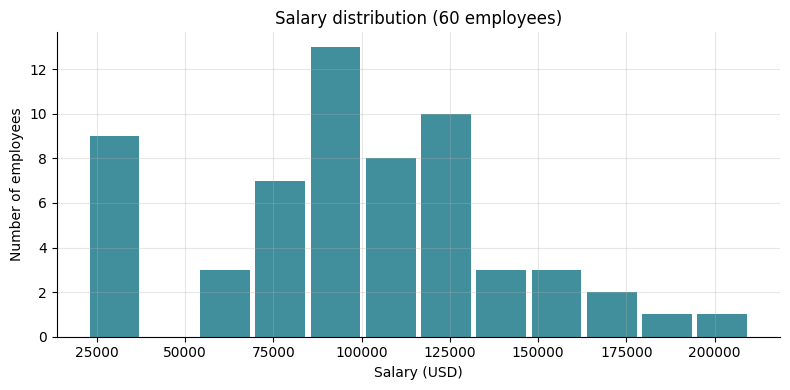

In [55]:
counts, edges = stats.histogram(salary, bins=12)

fig, ax = plt.subplots()
ax.bar(edges[:-1], counts, width=np.diff(edges) * 0.9, color="#1F7A8C", alpha=0.85)
ax.set_xlabel("Salary (USD)")
ax.set_ylabel("Number of employees")
ax.set_title("Salary distribution (60 employees)")
ax.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

#### Welford streaming statistics

In [56]:
w = stats.Welford()
for chunk in np.array_split(salary, 8):
    w.update(chunk)

print(f"Welford  mean : {w.mean_:,.2f}")
print(f"NumPy    mean : {salary.mean():,.2f}")
print(f"Welford  std  : {w.std:,.2f}")
print(f"NumPy    std  : {salary.std():,.2f}")
print(f"Agreement     : {np.isclose(w.mean_, salary.mean()) and np.isclose(w.std, salary.std())}")

Welford  mean : 106,028.58
NumPy    mean : 106,028.58
Welford  std  : 43,583.10
NumPy    std  : 43,583.10
Agreement     : True


### Finite-Difference Gradients (`optim.py`)


In [57]:
def f(x):
    return x[0]**2 + x[1]

g = optim.grad(f, [2, 3])

g_fwd = optim.grad(f, [2, 3], method="forward", h=1e-5)
g_central = optim.grad(f, [2, 3], method="central", h=1e-5)

print(f"Analytic gradient : {g}")
print(f"Forward difference  : {g_fwd}")
print(f"Central difference  : {g_central}")

Analytic gradient : [4. 1.]
Forward difference  : [4. 1.]
Central difference  : [4. 1.]


#### Jacobian of a linear map


In [58]:
def F(x):
    return np.array([x[0] + x[1], x[0] * x[1]])

J = optim.jacobian(F, [2, 3])
J_fwd = optim.jacobian(F, [2, 3], method="forward", h=1e-5)
J_central = optim.jacobian(F, [2, 3], method="central", h=1e-5)

print(f"Forward difference   :\n{J_fwd}")
print(f"Central difference   :\n{J_central}")

Forward difference   :
[[1. 1.]
 [3. 2.]]
Central difference   :
[[1. 1.]
 [3. 2.]]


### Benchmark

In [59]:
from numcompute import benchmarking

results = benchmarking.run_all(n_samples=100_000, seed=42)
print(results)


vectorised vs Python loops (n=100000)
Function                           Mean           Std           Min   Repeats
-------------------------------------------------------------------------------------
mean (Python loop)             3.881 ms     27.830 us      3.862 ms         3
mean (vectorised)             21.171 us      1.238 us     20.300 us         7
accuracy (Python loop)         8.063 ms    349.407 us      7.810 ms         3
accuracy (vectorised)         84.057 us      6.860 us     80.300 us         7
sum-sq-diff (Python loop)      8.633 ms    246.022 us      8.376 ms         3
sum-sq-diff (vectorised)      91.914 us      7.821 us     87.800 us         7


Speedup of vectorised over Python loop
--------------------------------------------------
  mean            :    183.3x faster
  accuracy        :     95.9x faster
  sum-sq-diff     :     93.9x faster


sort_search & rank — vectorised vs Python loop (n_large=100000, n_small=2000)
Function                             Mean     

### Pipeline Composition (`pipeline.py`)



In [60]:
from numcompute.pipeline import Pipeline

# Pipeline only over the numeric columns: impute → standardise
numeric_pipe = Pipeline([
    ("impute", preprocessing.SimpleImputer(30000)),
    ("scale",  preprocessing.StandardScaler()),
])

X_clean = numeric_pipe.fit_transform(X_num)
print(X_clean)

[[-0.186 -1.744 -0.301 -0.131 -0.363]
 [-0.185  0.396 -0.302 -0.133 -0.363]
 [-0.187 -0.235 -0.302 -0.13  -0.363]
 [ 5.385  0.675  3.317 -0.128 -0.363]
 [-0.186  0.367 -0.301 -0.132 -0.363]
 [-0.187 -0.248 -0.302 -0.129 -0.363]
 [-0.186 -0.09  -0.302 -0.131 -0.364]
 [-0.186 -0.53  -0.301 -0.13  -0.363]
 [-0.186 -0.281 -0.302 -0.132 -0.363]
 [-0.187  1.513 -0.302 -0.131 -0.363]
 [-0.185 -1.744 -0.301 -0.129 -0.364]
 [-0.185  0.15  -0.301 -0.13  -0.363]
 [-0.187 -0.638 -0.302 -0.128 -0.363]
 [-0.186  1.658 -0.302 -0.129 -0.363]
 [-0.187  0.655 -0.301 -0.13  -0.363]
 [-0.185  1.294  3.317 -0.128  2.752]
 [-0.185  0.629 -0.302 -0.13  -0.363]
 [ 5.385 -0.307 -0.302 -0.129 -0.363]
 [-0.184 -0.371 -0.301 -0.131 -0.363]
 [-0.185  2.102 -0.301 -0.13  -0.363]
 [-0.186 -1.744 -0.302 -0.131 -0.364]
 [-0.187 -0.793 -0.302 -0.129 -0.363]
 [-0.185  0.314 -0.302 -0.132 -0.363]
 [-0.184  0.692 -0.302 -0.129 -0.363]
 [-0.184 -1.744 -0.302 -0.131 -0.363]
 [-0.187  0.98   3.317 -0.129 -0.364]
 [-0.187  0.